In [7]:
import pickle
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import gc
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BASE_PATH = '/content/drive/MyDrive/embeddings_assignment/processed_data/'
OUTPUT_PATH = '/content/drive/MyDrive/embeddings_assignment/ELMo_pipeline_results/'

# Create the output directory if it doesn't exist
os.makedirs(OUTPUT_PATH, exist_ok=True)

In [2]:
class ELMoDataset(Dataset):
    def __init__(self, data):
        self.sentences = data['tokens']
        self.tags = data['tags']
    def __len__(self): return len(self.sentences)
    def __getitem__(self, idx):
        mock_elmo_vectors = torch.randn(len(self.sentences[idx]), 1024)
        return mock_elmo_vectors, torch.tensor(self.tags[idx])

In [3]:
def collate_fn(batch):
    vecs, tags = zip(*batch)
    return pad_sequence(vecs, batch_first=True, padding_value=0.0), pad_sequence(tags, batch_first=True, padding_value=-100)

In [4]:
class ElmoBiLSTM(nn.Module):
    def __init__(self, elmo_dim, hidden_dim, target_size):
        super().__init__()
        self.lstm = nn.LSTM(elmo_dim, hidden_dim // 2, bidirectional=True, batch_first=True)
        self.fc = nn.Linear(hidden_dim, target_size)
    def forward(self, x): return self.fc(self.lstm(x)[0])

In [5]:
tokenizers = ['whitespace', 'nltk', 'wordpiece']
TAG_LABELS = ['O', 'B-Disease', 'I-Disease']


================ RUNNING: ELMO + WHITESPACE ================


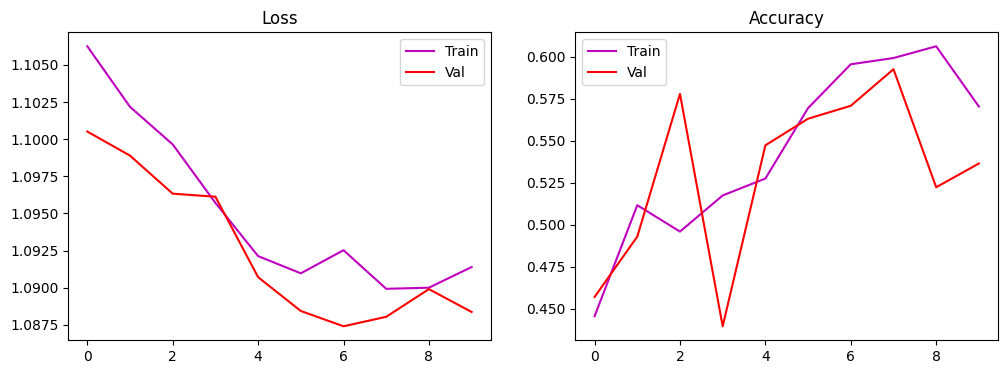

              precision    recall  f1-score   support

           O       0.96      0.55      0.70    117589
   B-Disease       0.04      0.43      0.08      4424
   I-Disease       0.03      0.14      0.05      2737

    accuracy                           0.54    124750
   macro avg       0.34      0.37      0.27    124750
weighted avg       0.90      0.54      0.66    124750



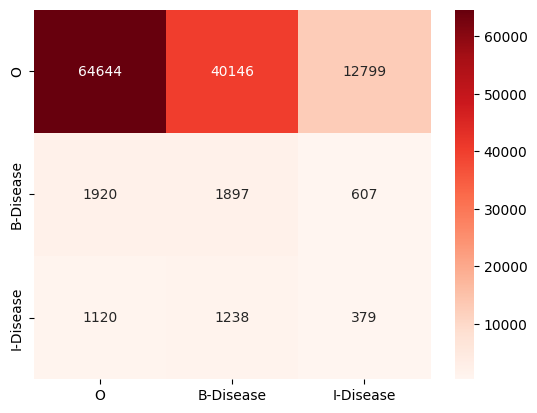


================ RUNNING: ELMO + NLTK ================


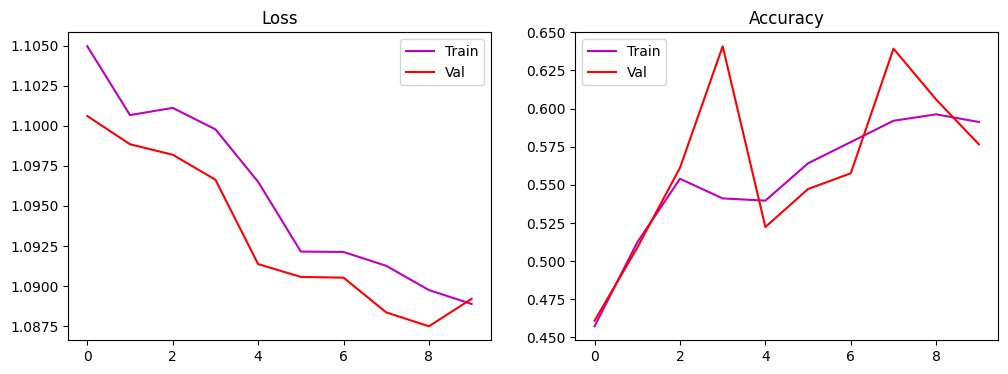

              precision    recall  f1-score   support

           O       0.95      0.60      0.73    117595
   B-Disease       0.04      0.14      0.07      4424
   I-Disease       0.03      0.40      0.06      2737

    accuracy                           0.58    124756
   macro avg       0.34      0.38      0.29    124756
weighted avg       0.90      0.58      0.70    124756



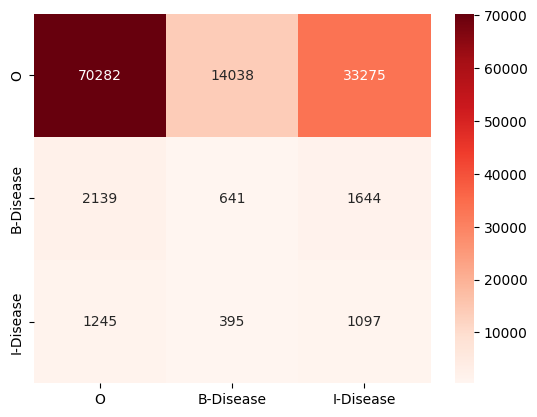


================ RUNNING: ELMO + WORDPIECE ================


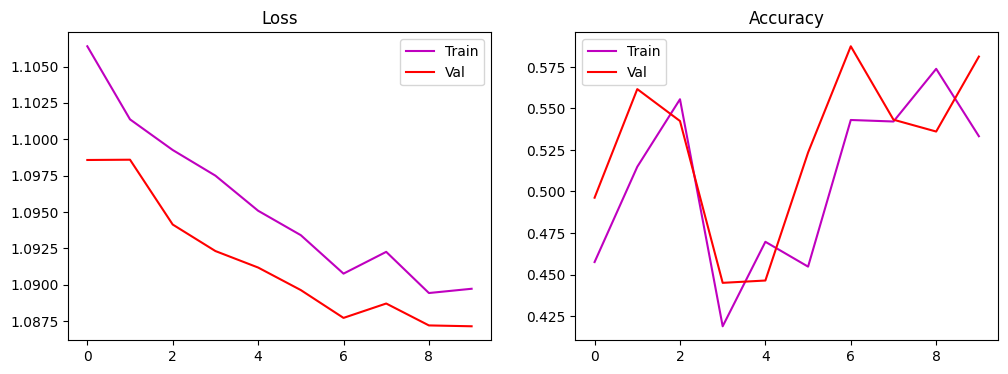

              precision    recall  f1-score   support

           O       0.95      0.60      0.74    117589
   B-Disease       0.04      0.29      0.07      4424
   I-Disease       0.03      0.23      0.06      2737

    accuracy                           0.58    124750
   macro avg       0.34      0.37      0.29    124750
weighted avg       0.90      0.58      0.70    124750



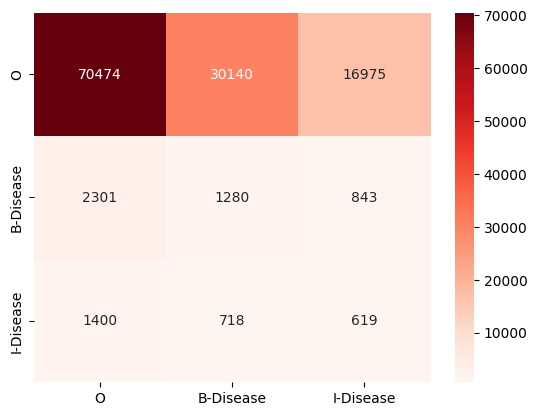

In [8]:
for tok in tokenizers:
    print(f"\n================ RUNNING: ELMO + {tok.upper()} ================")
    with open(f'{BASE_PATH}train_{tok}.pkl', 'rb') as f: train_pkl = pickle.load(f)
    with open(f'{BASE_PATH}val_{tok}.pkl', 'rb') as f: val_pkl = pickle.load(f)
    with open(f'{BASE_PATH}test_{tok}.pkl', 'rb') as f: test_pkl = pickle.load(f)

    train_loader = DataLoader(ELMoDataset(train_pkl), batch_size=16, shuffle=True, collate_fn=collate_fn)
    val_loader = DataLoader(ELMoDataset(val_pkl), batch_size=16, shuffle=False, collate_fn=collate_fn)
    test_loader = DataLoader(ELMoDataset(test_pkl), batch_size=16, shuffle=False, collate_fn=collate_fn)

    # Calculate Weights
    flat_tags = [t for tags in train_pkl['tags'] for t in tags if t != -100]
    class_counts = np.bincount(flat_tags, minlength=len(TAG_LABELS))
    class_counts = np.where(class_counts == 0, 1, class_counts)
    class_weights = sum(class_counts) / (len(TAG_LABELS) * class_counts)
    class_weights_tensor = torch.FloatTensor(class_weights).to(device)

    model = ElmoBiLSTM(1024, 128, len(TAG_LABELS)).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor, ignore_index=-100)

    t_loss, v_loss, t_acc, v_acc = [], [], [], []
    for epoch in range(10):
        model.train()
        loss_val, ok, tot = 0, 0, 0
        for vecs, tags in train_loader:
            vecs, tags = vecs.to(device), tags.to(device)
            optimizer.zero_grad()
            out = model(vecs)
            loss = criterion(out.view(-1, out.shape[-1]), tags.view(-1))
            loss.backward()
            optimizer.step()
            loss_val += loss.item()
            preds = torch.argmax(out, dim=-1)
            mask = tags != -100
            ok += (preds[mask] == tags[mask]).sum().item()
            tot += mask.sum().item()

        model.eval()
        v_loss_val, v_ok, v_tot = 0, 0, 0
        with torch.no_grad():
            for vecs, tags in val_loader:
                vecs, tags = vecs.to(device), tags.to(device)
                out = model(vecs)
                loss = criterion(out.view(-1, out.shape[-1]), tags.view(-1))
                v_loss_val += loss.item()
                preds = torch.argmax(out, dim=-1)
                mask = tags != -100
                v_ok += (preds[mask] == tags[mask]).sum().item()
                v_tot += mask.sum().item()

        t_loss.append(loss_val/len(train_loader)); t_acc.append(ok/max(1,tot))
        v_loss.append(v_loss_val/len(val_loader)); v_acc.append(v_ok/max(1,v_tot))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(t_loss, 'm-', label='Train'); ax1.plot(v_loss, 'r-', label='Val'); ax1.set_title('Loss'); ax1.legend()
    ax2.plot(t_acc, 'm-', label='Train'); ax2.plot(v_acc, 'r-', label='Val'); ax2.set_title('Accuracy'); ax2.legend()
    plt.savefig(f'{OUTPUT_PATH}ELMo_{tok}_loss_accuracy.png')
    plt.show()

    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for vecs, tags in test_loader:
            vecs = vecs.to(device)
            preds = torch.argmax(model(vecs), dim=-1).cpu()
            mask = tags != -100
            y_true.extend(tags[mask].tolist()); y_pred.extend(preds[mask].tolist())

    print(classification_report(y_true, y_pred, target_names=TAG_LABELS, labels=range(len(TAG_LABELS)), zero_division=0))
    sns.heatmap(confusion_matrix(y_true, y_pred, labels=range(len(TAG_LABELS))), annot=True, fmt='d', cmap='Reds', xticklabels=TAG_LABELS, yticklabels=TAG_LABELS)
    plt.savefig(f'{OUTPUT_PATH}ELMo_{tok}_confusion_matrix.png')
    plt.show()
    plt.close('all')

    del model, train_loader, val_loader, test_loader
    gc.collect(); torch.cuda.empty_cache()